# Exercício 2 — Item B: Pipeline Integrativo de Visão Computacional

Este notebook integra de forma sequencial as técnicas abordadas ao longo da disciplina:
1. **Calibração e Retificação de Câmera** (Exercício 1A - `cv2.undistort`)
2. **Segmentação Cromática no Espaço HSV** (TP1 - Binarização e ROI)
3. **Extração de Descritores Locais Invariantes ORB** (TP2 - Keypoints)
4. **Detecção de Pedestres/Faces** (TP3 - Haar Cascade / HOG+SVM)
5. **Classificação Profunda com OpenCV DNN** (Exercício 2A - SqueezeNet v1.1)


In [1]:
import time
import cv2
import matplotlib.pyplot as plt
import numpy as np
from utils import (
    ensure_dirs,
    obter_frame_pipeline,
    obter_labels_imagenet,
    obter_modelo_squeezenet,
    CALIB_FILE,
    SAIDAS_DIR
)

ensure_dirs()
print('Ambiente e bibliotecas carregados com sucesso!')


Ambiente e bibliotecas carregados com sucesso!


## 1. Carregamento da Calibração, Imagem Real e Modelo SqueezeNet DNN


In [2]:
# Carregar parâmetros de calibração do Ex 1A
if CALIB_FILE.exists():
    dados_calib = np.load(CALIB_FILE)
    K = dados_calib['K']
    dist = dados_calib['dist']
    print('Matriz K e distorção carregadas de:', CALIB_FILE.name)
else:
    K = np.array([[600.0, 0.0, 320.0], [0.0, 600.0, 240.0], [0.0, 0.0, 1.0]], dtype=np.float32)
    dist = np.array([[-0.15, 0.05, 0.0, 0.0, 0.0]], dtype=np.float32)
    print('[!] Calibração padrão de contingência.')

# Carregar frame real (pessoa.jpg / biblioteca)
frame_raw, caminho_frame = obter_frame_pipeline()
print(f'Frame de teste carregado de {caminho_frame.name} com dimensões: {frame_raw.shape}')

# Carregar SqueezeNet v1.1 e labels do ImageNet
net, _, _ = obter_modelo_squeezenet()
labels = obter_labels_imagenet()
print(f'Rede SqueezeNet carregada via OpenCV DNN ({len(labels)} classes)')


Matriz K e distorção carregadas de: calibracao_camera.npz
Frame de teste carregado de pessoa.jpg com dimensões: (626, 626, 3)
Rede SqueezeNet carregada via OpenCV DNN (1000 classes)


## 2. Execução Sequencial das 5 Etapas do Pipeline com Cronometragem


In [3]:
tempos = {}

# Etapa 1: Retificação Geométrica (cv2.undistort)
t0 = time.perf_counter()
frame_corrigido = cv2.undistort(frame_raw, K, dist)
tempos['1. Undistort (Ex 1)'] = (time.perf_counter() - t0) * 1000.0

# Etapa 2: Segmentação por Cor HSV e Morfologia (TP1)
t0 = time.perf_counter()
hsv = cv2.cvtColor(frame_corrigido, cv2.COLOR_BGR2HSV)
m1 = cv2.inRange(hsv, np.array([0, 30, 60]), np.array([25, 255, 255]))
m2 = cv2.inRange(hsv, np.array([170, 50, 50]), np.array([180, 255, 255]))
mask_hsv = cv2.bitwise_or(m1, m2)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
mask_hsv = cv2.morphologyEx(mask_hsv, cv2.MORPH_OPEN, kernel)
mask_hsv = cv2.morphologyEx(mask_hsv, cv2.MORPH_CLOSE, kernel)
cnts, _ = cv2.findContours(mask_hsv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
rx, ry, rw, rh = 20, 38, 434, 588
if cnts:
    c_max = max(cnts, key=cv2.contourArea)
    if cv2.contourArea(c_max) > 500:
        rx, ry, rw, rh = cv2.boundingRect(c_max)
roi_img = frame_corrigido[ry:ry + rh, rx:rx + rw]
tempos['2. Segmentação HSV (TP1)'] = (time.perf_counter() - t0) * 1000.0

# Etapa 3: Descritores Locais e Pontos-Chave ORB (TP2)
t0 = time.perf_counter()
gray_roi = cv2.cvtColor(roi_img, cv2.COLOR_BGR2GRAY)
orb = cv2.ORB_create(nfeatures=120)
kps, _ = orb.detectAndCompute(gray_roi, None)
tempos['3. Features ORB (TP2)'] = (time.perf_counter() - t0) * 1000.0

# Etapa 4: Detecção de Pessoas/Faces (TP3)
t0 = time.perf_counter()
boxes_det = []
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)
gray_frame = cv2.cvtColor(frame_corrigido, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray_frame, 1.1, 4, minSize=(60, 60))
for (fx, fy, fw, fh) in faces:
    boxes_det.append(('Haar: Face (TP3)', [int(fx), int(fy), int(fw), int(fh)]))
tempos['4. Detector Pessoas/Faces (TP3)'] = (time.perf_counter() - t0) * 1000.0

# Etapa 5: Classificação Profunda OpenCV DNN SqueezeNet (Ex 2A)
t0 = time.perf_counter()
blob = cv2.dnn.blobFromImage(roi_img, 1.0, (227, 227), (104.0, 117.0, 123.0), swapRB=False)
net.setInput(blob)
out = net.forward()
logits = out.flatten()
e_x = np.exp(logits - np.max(logits))
probs = e_x / e_x.sum(axis=0)
top3_idx = np.argsort(probs)[::-1][:3]
top3 = [(labels[i], float(probs[i])) for i in top3_idx]
tempos['5. Classificação DNN (Ex 2A)'] = (time.perf_counter() - t0) * 1000.0

tempo_total = sum(tempos.values())
print('-' * 55)
print('TEMPOS DE EXECUÇÃO POR ETAPA:')
print('-' * 55)
for k, v in tempos.items():
    print(f'{k:<30} : {v:6.2f} ms ({v/tempo_total*100:4.1f}%)')
print('-' * 55)
print(f'TEMPO TOTAL: {tempo_total:6.2f} ms ({1000/tempo_total:.1f} FPS)')


-------------------------------------------------------
TEMPOS DE EXECUÇÃO POR ETAPA:
-------------------------------------------------------
1. Undistort (Ex 1)            :  11.29 ms ( 1.4%)
2. Segmentação HSV (TP1)       :   2.63 ms ( 0.3%)
3. Features ORB (TP2)          : 740.40 ms (92.1%)
4. Detector Pessoas/Faces (TP3) :  29.53 ms ( 3.7%)
5. Classificação DNN (Ex 2A)   :  20.29 ms ( 2.5%)
-------------------------------------------------------
TEMPO TOTAL: 804.14 ms (1.2 FPS)


## 3. Visualização Integrada com Todas as Anotações Sobrepostas


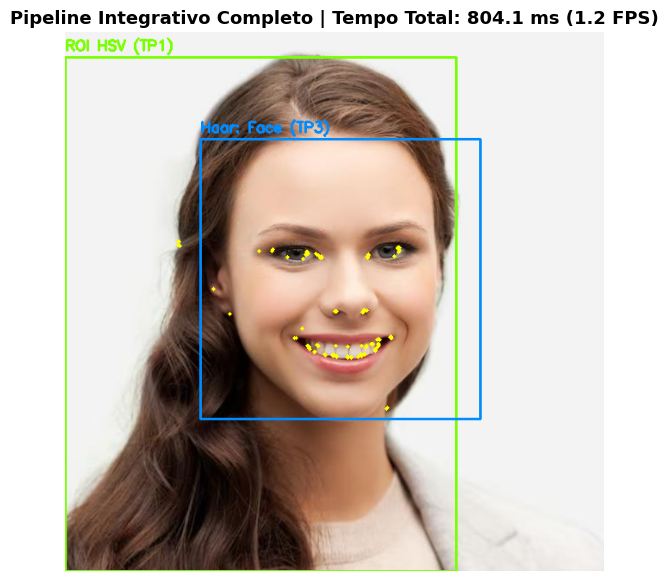

In [4]:
vis = frame_corrigido.copy()
# 1. ROI HSV
cv2.rectangle(vis, (rx, ry), (rx + rw, ry + rh), (0, 255, 120), 2)
cv2.putText(vis, 'ROI HSV (TP1)', (rx, ry - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 120), 2)

# 2. ORB Keypoints
for kp in kps:
    cv2.circle(vis, (int(kp.pt[0] + rx), int(kp.pt[1] + ry)), 2, (0, 255, 255), -1)

# 3. Detecções Haar
for rotulo, (bx, by, bw, bh) in boxes_det:
    cv2.rectangle(vis, (bx, by), (bx + bw, by + bh), (255, 140, 0), 2)
    cv2.putText(vis, rotulo, (bx, by - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 140, 0), 2)

# 4. Top-1 Classificação DNN
top1_txt = f'{top3[0][0]}: {top3[0][1]*100:.1f}%'
cv2.putText(vis, f'DNN: {top1_txt}', (rx, ry + rh + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 255), 2)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'Pipeline Integrativo Completo | Tempo Total: {tempo_total:.1f} ms ({1000/tempo_total:.1f} FPS)', fontsize=13, fontweight='bold')
plt.axis('off')
plt.show()
